# Customer Churn Analysis
**Mini Project | Data Analytics**

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** Telecom Customer Churn Dataset (7043 records)

---
## PART 1 — DATA LOADING

In [1]:
# ── Step 1: Import required libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (8, 5)

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# ── Step 2: Load the dataset ────────────────────────────────────────────────
df = pd.read_csv('../Dataset/Customer_Churn_Raw.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded: 7048 rows × 21 columns


In [3]:
# ── Step 3: First five records ──────────────────────────────────────────────
df.head()

,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,CUST-00001,Male,0,Yes,No,43,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,No,Credit card (automatic),53.11,2280.74,No
1,CUST-00002,Female,1,Yes,Yes,69,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,42.67,2944.56,No
2,CUST-00003,Male,0,No,Yes,63,Yes,No,DSL,No,...,No,Yes,Yes,No,Two year,Yes,Mailed check,49.57,3114.97,No
3,CUST-00004,Male,0,Yes,No,70,Yes,No,Fiber optic,Yes,...,Yes,No,No,No,Month-to-month,Yes,Bank transfer (automatic),78.88,5513.77,Yes
4,CUST-00005,Male,0,Yes,No,65,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,No,Month-to-month,Yes,Bank transfer (automatic),47.10,3052.29,Yes


In [4]:
# ── Step 4: Last five records ───────────────────────────────────────────────
df.tail()

,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
7043,CUST-03281,Female,0,Yes,No,71,Yes,Yes,DSL,No,...,No,No,No,No,One year,Yes,Bank transfer (automatic),43.74,3102.21,No
7044,CUST-06940,Female,0,No,No,25,Yes,Yes,DSL,No,...,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),55.99,1402.37,No
7045,CUST-01839,Female,1,No,Yes,28,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),39.23,1094.33,Yes
7046,CUST-00715,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,No,Month-to-month,Yes,Mailed check,74.14,71.82,No
7047,CUST-03428,Male,1,Yes,No,67,Yes,No,DSL,No,...,No,No,No,Yes,One year,Yes,Mailed check,66.20,4444.85,No


In [5]:
# ── Step 5: Dataset shape ───────────────────────────────────────────────────
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows   : 7048
Columns: 21


In [6]:
# ── Step 6: Column names ────────────────────────────────────────────────────
print('Column names:')
for col in df.columns:
    print(f'  • {col}')

Column names:
  • Customer_ID
  • Gender
  • Senior_Citizen
  • Partner
  • Dependents
  • Tenure_Months
  • Phone_Service
  • Multiple_Lines
  • Internet_Service
  • Online_Security
  • Online_Backup
  • Device_Protection
  • Tech_Support
  • Streaming_TV
  • Streaming_Movies
  • Contract
  • Paperless_Billing
  • Payment_Method
  • Monthly_Charges
  • Total_Charges
  • Churn


---
## PART 2 — DATA EXPLORATION & CLEANING

In [7]:
# ── Step 7: Data types ──────────────────────────────────────────────────────
df.dtypes

Customer_ID           object
Gender                object
Senior_Citizen         int64
Partner               object
Dependents            object
Tenure_Months          int64
Phone_Service         object
Multiple_Lines        object
Internet_Service      object
Online_Security       object
Online_Backup         object
Device_Protection     object
Tech_Support          object
Streaming_TV          object
Streaming_Movies      object
Contract              object
Paperless_Billing     object
Payment_Method        object
Monthly_Charges      float64
Total_Charges        float64
Churn                 object
dtype: object

In [8]:
# ── Step 8: Statistical information ────────────────────────────────────────
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,7048,7043,CUST-01839,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7048,2,Male,3551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Senior_Citizen,7048.0,NaN,NaN,NaN,0.153802,0.360785,0.0,0.0,0.0,0.0,1.0
Partner,7048,2,No,3545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7048,2,No,5042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,7048.0,NaN,NaN,NaN,36.35996,20.63626,1.0,19.0,36.0,54.0,72.0
Phone_Service,7048,2,Yes,6380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Multiple_Lines,7048,3,No,3237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Service,7048,3,Fiber optic,3070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Online_Security,7048,3,No,3881,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# ── Step 9: Missing values ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                 Missing Count  Missing %
Monthly_Charges             10       0.14
Total_Charges               10       0.14


In [10]:
# ── Step 10: Check duplicate records ───────────────────────────────────────
dup_count = df.duplicated().sum()
print(f'Duplicate rows found: {dup_count}')

Duplicate rows found: 5


In [11]:
# ── Step 11: Remove duplicates ──────────────────────────────────────────────
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after removing duplicates: {df.shape}')

Shape after removing duplicates: (7043, 21)


In [12]:
# ── Step 12: Unique values per column ──────────────────────────────────────
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 10:
        print(f'{col:25s} ({n_unique} unique): {df[col].unique().tolist()}')
    else:
        print(f'{col:25s} ({n_unique} unique values)')

Customer_ID               (7043 unique values)
Gender                    (2 unique): ['Male', 'Female']
Senior_Citizen            (2 unique): [0, 1]
Partner                   (2 unique): ['Yes', 'No']
Dependents                (2 unique): ['No', 'Yes']
Tenure_Months             (72 unique values)
Phone_Service             (2 unique): ['Yes', 'No']
Multiple_Lines            (3 unique): ['No', 'Yes', 'No phone service']
Internet_Service          (3 unique): ['DSL', 'Fiber optic', 'No']
Online_Security           (3 unique): ['No', 'Yes', 'No internet service']
Online_Backup             (3 unique): ['No', 'No internet service', 'Yes']
Device_Protection         (3 unique): ['No', 'Yes', 'No internet service']
Tech_Support              (3 unique): ['No', 'Yes', 'No internet service']
Streaming_TV              (3 unique): ['Yes', 'No', 'No internet service']
Streaming_Movies          (3 unique): ['No', 'No internet service', 'Yes']
Contract                  (3 unique): ['Month-to-month', 'Two

Paperless_Billing         (2 unique): ['No', 'Yes']
Payment_Method            (4 unique): ['Credit card (automatic)', 'Mailed check', 'Bank transfer (automatic)', 'Electronic check']
Monthly_Charges           (4401 unique values)
Total_Charges             (6980 unique values)
Churn                     (2 unique): ['No', 'Yes']


In [13]:
# ── Step 13: Handle missing values ─────────────────────────────────────────
# Fill Monthly_Charges missing with median
mc_median = df['Monthly_Charges'].median()
df['Monthly_Charges'] = df['Monthly_Charges'].fillna(mc_median)

# Fill Total_Charges missing with Tenure × Monthly_Charges (imputed)
mask = df['Total_Charges'].isnull()
df.loc[mask, 'Total_Charges'] = df.loc[mask, 'Tenure_Months'] * df.loc[mask, 'Monthly_Charges']

print('Missing values after handling:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No remaining missing values.' if df.isnull().sum().sum() == 0 else '')

Missing values after handling:


Series([], dtype: int64)
No remaining missing values.


In [14]:
# ── Step 14: Convert data types ─────────────────────────────────────────────
# Ensure numeric types
df['Monthly_Charges'] = pd.to_numeric(df['Monthly_Charges'], errors='coerce')
df['Total_Charges']   = pd.to_numeric(df['Total_Charges'],   errors='coerce')
df['Tenure_Months']   = pd.to_numeric(df['Tenure_Months'],   errors='coerce')
df['Senior_Citizen']  = df['Senior_Citizen'].astype(int)

# Convert categorical columns
cat_cols = ['Gender', 'Partner', 'Dependents', 'Phone_Service', 'Multiple_Lines',
            'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection',
            'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract',
            'Paperless_Billing', 'Payment_Method', 'Churn']
for col in cat_cols:
    df[col] = df[col].astype('category')

print('Data types updated:')
print(df.dtypes)

Data types updated:
Customer_ID            object
Gender               category
Senior_Citizen          int64
Partner              category
Dependents           category
Tenure_Months           int64
Phone_Service        category
Multiple_Lines       category
Internet_Service     category
Online_Security      category
Online_Backup        category
Device_Protection    category
Tech_Support         category
Streaming_TV         category
Streaming_Movies     category
Contract             category
Paperless_Billing    category
Payment_Method       category
Monthly_Charges       float64
Total_Charges         float64
Churn                category
dtype: object


In [15]:
# ── Step 15: Create Tenure Groups ──────────────────────────────────────────
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0–12 Months', '13–24 Months', '25–36 Months',
          '37–48 Months', '49–60 Months', '61–72 Months']
df['Tenure_Group'] = pd.cut(df['Tenure_Months'], bins=bins, labels=labels, right=True)
print('Tenure group distribution:')
print(df['Tenure_Group'].value_counts().sort_index())

Tenure group distribution:
Tenure_Group
0–12 Months     1134
13–24 Months    1202
25–36 Months    1201
37–48 Months    1212
49–60 Months    1134
61–72 Months    1160
Name: count, dtype: int64


In [16]:
# ── Step 16: Verify cleaned dataset ────────────────────────────────────────
print('=== Cleaned Dataset Summary ===')
print(f'Shape         : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
print()
df.head(3)

=== Cleaned Dataset Summary ===
Shape         : (7043, 22)


Missing values: 0
Duplicates    : 0



,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn,Tenure_Group
0,CUST-00001,Male,0,Yes,No,43,Yes,No,DSL,No,...,No,Yes,No,Month-to-month,No,Credit card (automatic),53.11,2280.74,No,37–48 Months
1,CUST-00002,Female,1,Yes,Yes,69,Yes,Yes,DSL,No,...,No,No,No,Month-to-month,Yes,Mailed check,42.67,2944.56,No,61–72 Months
2,CUST-00003,Male,0,No,Yes,63,Yes,No,DSL,No,...,Yes,Yes,No,Two year,Yes,Mailed check,49.57,3114.97,No,61–72 Months


In [17]:
# ── Export cleaned dataset ──────────────────────────────────────────────────
df.to_csv('../Dataset/Customer_Churn_Cleaned.csv', index=False)
print('Cleaned dataset saved to ../Dataset/Customer_Churn_Cleaned.csv')

Cleaned dataset saved to ../Dataset/Customer_Churn_Cleaned.csv


---
## PART 3 — DATA ANALYSIS

In [18]:
# ── Step 17–23: Core KPIs ───────────────────────────────────────────────────
total_customers   = len(df)                                      # Step 17
churned           = (df['Churn'] == 'Yes').sum()                 # Step 18
retained          = (df['Churn'] == 'No').sum()                  # Step 19
churn_rate        = round(churned / total_customers * 100, 2)    # Step 20
avg_monthly       = round(df['Monthly_Charges'].mean(), 2)       # Step 21
avg_total         = round(df['Total_Charges'].mean(), 2)         # Step 22
avg_tenure        = round(df['Tenure_Months'].mean(), 2)         # Step 23

print('─' * 40)
print(f' Total Customers        : {total_customers:,}')
print(f' Churned Customers      : {churned:,}')
print(f' Retained Customers     : {retained:,}')
print(f' Overall Churn Rate     : {churn_rate}%')
print(f' Avg Monthly Charges    : ${avg_monthly}')
print(f' Avg Total Charges      : ${avg_total}')
print(f' Avg Tenure (Months)    : {avg_tenure}')
print('─' * 40)

────────────────────────────────────────
 Total Customers        : 7,043
 Churned Customers      : 2,415
 Retained Customers     : 4,628
 Overall Churn Rate     : 34.29%
 Avg Monthly Charges    : $60.26
 Avg Total Charges      : $2189.57
 Avg Tenure (Months)    : 36.36
────────────────────────────────────────


In [19]:
# ── Step 24: Customers by Gender ────────────────────────────────────────────
gender_dist = df['Gender'].value_counts()
print('Customers by Gender:')
print(gender_dist.to_string())

Customers by Gender:
Gender
Male      3550
Female    3493


In [20]:
# ── Step 25: Customers by Contract ─────────────────────────────────────────
contract_dist = df['Contract'].value_counts()
print('Customers by Contract Type:')
print(contract_dist.to_string())

Customers by Contract Type:
Contract
Month-to-month    3880
Two year          1635
One year          1528


In [21]:
# ── Step 26: Customers by Internet Service ──────────────────────────────────
internet_dist = df['Internet_Service'].value_counts()
print('Customers by Internet Service:')
print(internet_dist.to_string())

Customers by Internet Service:
Internet_Service
Fiber optic    3069
DSL            2368
No             1606


In [22]:
# ── Step 27: Customers by Payment Method ───────────────────────────────────
payment_dist = df['Payment_Method'].value_counts()
print('Customers by Payment Method:')
print(payment_dist.to_string())

Customers by Payment Method:
Payment_Method
Electronic check             2368
Mailed check                 1610
Bank transfer (automatic)    1583
Credit card (automatic)      1482


In [23]:
# ── Helper: churn rate function ─────────────────────────────────────────────
def churn_rate_by(col):
    ct = df.groupby(col, observed=True)['Churn'].value_counts(normalize=True).unstack().fillna(0)
    ct.columns = [f'Churn_{c}' for c in ct.columns]
    ct = ct.rename(columns={'Churn_Yes': 'Churn_Rate', 'Churn_No': 'Retained_Rate'})
    ct['Churn_Rate'] = (ct['Churn_Rate'] * 100).round(2)
    return ct[['Churn_Rate']].sort_values('Churn_Rate', ascending=False)

In [24]:
# ── Step 28: Churn Rate by Gender ───────────────────────────────────────────
print('Churn Rate by Gender (%):')
print(churn_rate_by('Gender').to_string())

Churn Rate by Gender (%):
        Churn_Rate
Gender            
Male         34.54
Female       34.04


In [25]:
# ── Step 29: Churn Rate by Contract ────────────────────────────────────────
print('Churn Rate by Contract Type (%):')
print(churn_rate_by('Contract').to_string())

Churn Rate by Contract Type (%):
                Churn_Rate
Contract                  
Month-to-month       49.48
One year             23.89
Two year              7.95


In [26]:
# ── Step 30: Churn Rate by Internet Service ─────────────────────────────────
print('Churn Rate by Internet Service (%):')
print(churn_rate_by('Internet_Service').to_string())

Churn Rate by Internet Service (%):
                  Churn_Rate
Internet_Service            
Fiber optic            41.74
No                     29.64
DSL                    27.79


In [27]:
# ── Step 31: Churn Rate by Payment Method ──────────────────────────────────
print('Churn Rate by Payment Method (%):')
print(churn_rate_by('Payment_Method').to_string())

Churn Rate by Payment Method (%):


                           Churn_Rate
Payment_Method                       
Electronic check                38.98
Mailed check                    33.48
Bank transfer (automatic)       32.09
Credit card (automatic)         30.03


In [28]:
# ── Step 32: Churn Rate by Senior Citizen ──────────────────────────────────
senior_churn = df.groupby('Senior_Citizen')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2).rename(index={0: 'Non-Senior', 1: 'Senior'})
print('Churn Rate by Senior Citizen Status (%):')
print(senior_churn.to_string())

Churn Rate by Senior Citizen Status (%):
Senior_Citizen
Non-Senior    33.51
Senior        38.58


In [29]:
# ── Step 33: Churn Rate by Tenure Group ────────────────────────────────────
tenure_churn = df.groupby('Tenure_Group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)
print('Churn Rate by Tenure Group (%):')
print(tenure_churn.to_string())

Churn Rate by Tenure Group (%):
Tenure_Group
0–12 Months     46.30
13–24 Months    33.28
25–36 Months    35.64
37–48 Months    35.15
49–60 Months    28.22
61–72 Months    27.24


In [30]:
# ── Step 34: Compare Monthly Charges — Churned vs Retained ─────────────────
mc_compare = df.groupby('Churn', observed=True)['Monthly_Charges'].agg(['mean', 'median', 'std']).round(2)
mc_compare.columns = ['Mean', 'Median', 'Std Dev']
print('Monthly Charges — Churned vs Retained:')
print(mc_compare.to_string())

Monthly Charges — Churned vs Retained:
        Mean  Median  Std Dev
Churn                        
No     58.65   60.87    21.28
Yes    63.34   67.86    21.29


In [31]:
# ── Step 35: Compare Tenure — Churned vs Retained ──────────────────────────
tenure_compare = df.groupby('Churn', observed=True)['Tenure_Months'].agg(['mean', 'median', 'std']).round(2)
tenure_compare.columns = ['Mean', 'Median', 'Std Dev']
print('Tenure (Months) — Churned vs Retained:')
print(tenure_compare.to_string())

Tenure (Months) — Churned vs Retained:
        Mean  Median  Std Dev
Churn                        
No     38.04    38.0    20.41
Yes    33.13    32.0    20.67


In [32]:
# ── Step 36: Top 10 Customers by Total Charges ──────────────────────────────
top10 = df.nlargest(10, 'Total_Charges')[['Customer_ID', 'Tenure_Months', 'Monthly_Charges',
                                           'Total_Charges', 'Contract', 'Churn']]
print('Top 10 Customers by Total Charges:')
print(top10.to_string(index=False))

Top 10 Customers by Total Charges:
Customer_ID  Tenure_Months  Monthly_Charges  Total_Charges       Contract Churn
 CUST-01629             72            93.50        6731.86       Two year    No
 CUST-03749             72            93.27        6713.20 Month-to-month    No
 CUST-05677             71            94.26        6702.15 Month-to-month   Yes
 CUST-03565             72            92.38        6643.07       Two year    No
 CUST-04030             72            92.00        6626.11       One year    No
 CUST-01570             71            93.09        6611.07       Two year    No
 CUST-00417             72            91.61        6588.34 Month-to-month   Yes
 CUST-02197             70            93.74        6557.73 Month-to-month   Yes
 CUST-00427             70            93.74        6555.53 Month-to-month    No
 CUST-03205             70            93.40        6540.21       Two year    No


In [33]:
# ── Step 37: Customer Segments with Higher Churn ────────────────────────────
seg = df.groupby(['Contract', 'Internet_Service', 'Senior_Citizen'], observed=True).apply(
    lambda x: pd.Series({
        'Count': len(x),
        'Churned': (x['Churn'] == 'Yes').sum(),
        'Churn_Rate_%': round((x['Churn'] == 'Yes').mean() * 100, 2)
    })
).reset_index()
print('Top customer segments by churn rate (min 30 customers):')
top_seg = seg[seg['Count'] >= 30].sort_values('Churn_Rate_%', ascending=False).head(10)
print(top_seg.to_string(index=False))

Top customer segments by churn rate (min 30 customers):


      Contract Internet_Service  Senior_Citizen  Count  Churned  Churn_Rate_%
Month-to-month      Fiber optic               1  257.0    177.0         68.87
Month-to-month      Fiber optic               0 1446.0    800.0         55.33
Month-to-month               No               1  108.0     54.0         50.00
Month-to-month              DSL               1  196.0     95.0         48.47
Month-to-month               No               0  755.0    337.0         44.64
Month-to-month              DSL               0 1118.0    457.0         40.88
      One year      Fiber optic               1  108.0     36.0         33.33
      One year      Fiber optic               0  565.0    183.0         32.39
      One year               No               0  286.0     56.0         19.58
      Two year      Fiber optic               1  121.0     21.0         17.36


In [34]:
# ── Step 38: Major Factors Associated with Churn ────────────────────────────
# Binary encode Churn for correlation
df['Churn_Numeric'] = (df['Churn'] == 'Yes').astype(int)

# Numeric features correlation
num_corr = df[['Churn_Numeric', 'Tenure_Months', 'Monthly_Charges',
               'Total_Charges', 'Senior_Citizen']].corr()['Churn_Numeric'].drop('Churn_Numeric')

print('Correlation with Churn (numeric features):')
print(num_corr.sort_values(key=abs, ascending=False).to_string())

print()
# Categorical churn rates
for col in ['Contract', 'Internet_Service', 'Payment_Method', 'Gender']:
    cr = df.groupby(col, observed=True)['Churn_Numeric'].mean().mul(100).round(2)
    print(f'  Churn rate by {col}:')
    print(cr.sort_values(ascending=False).to_string())
    print()

Correlation with Churn (numeric features):
Tenure_Months     -0.112977
Monthly_Charges    0.104150
Total_Charges     -0.043232
Senior_Citizen     0.038448

  Churn rate by Contract:
Contract
Month-to-month    49.48
One year          23.89
Two year           7.95

  Churn rate by Internet_Service:
Internet_Service
Fiber optic    41.74
No             29.64
DSL            27.79

  Churn rate by Payment_Method:
Payment_Method
Electronic check             38.98
Mailed check                 33.48
Bank transfer (automatic)    32.09
Credit card (automatic)      30.03

  Churn rate by Gender:
Gender
Male      34.54
Female    34.04



---
## PART 4 — PYTHON VISUALIZATION

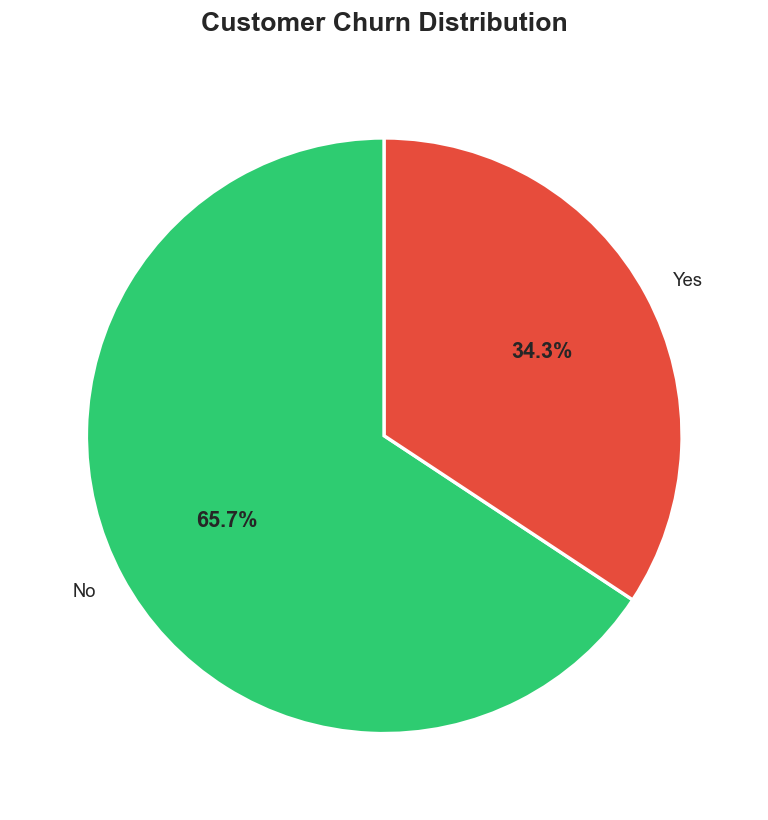

In [35]:
# ── VIZ 1: Churn Distribution — Pie Chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax.set_title('Customer Churn Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../Dataset/viz_01_churn_distribution.png', bbox_inches='tight')
plt.show()

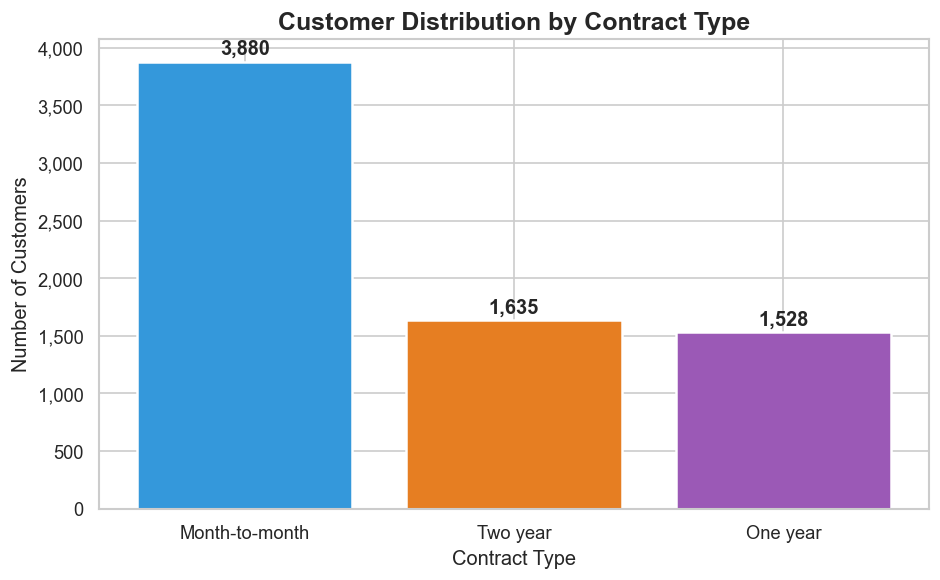

In [36]:
# ── VIZ 2: Customer Distribution by Contract — Bar Chart ────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
contract_counts = df['Contract'].value_counts()
bars = ax.bar(contract_counts.index, contract_counts.values,
              color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='white', linewidth=1.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Customer Distribution by Contract Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../Dataset/viz_02_contract_distribution.png', bbox_inches='tight')
plt.show()

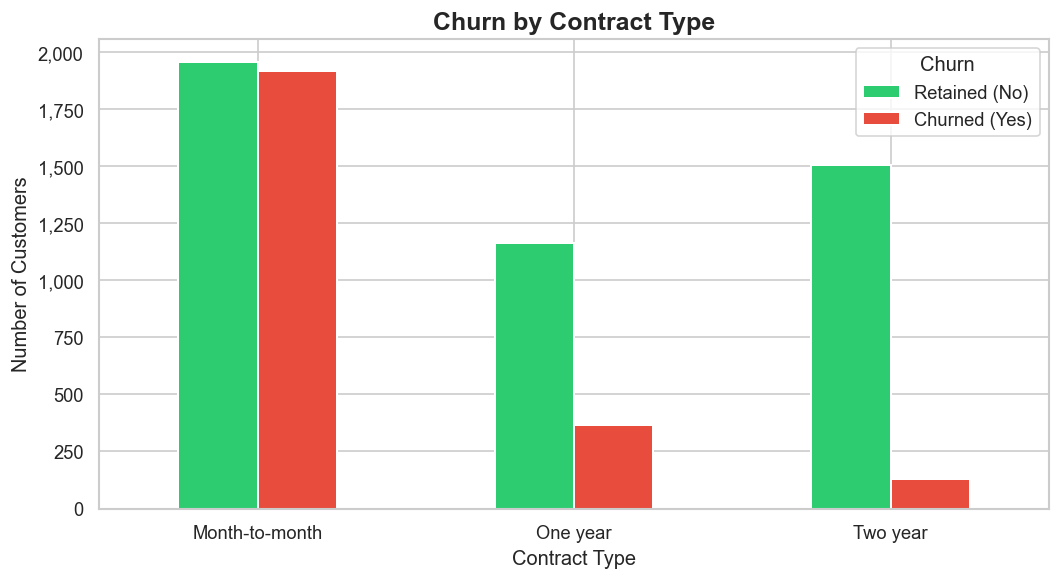

In [37]:
# ── VIZ 3: Churn by Contract — Grouped Bar Chart ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
churn_contract = df.groupby(['Contract', 'Churn'], observed=True).size().unstack()
churn_contract.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
                    edgecolor='white', linewidth=1.2, rot=0)
ax.set_title('Churn by Contract Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Churn', labels=['Retained (No)', 'Churned (Yes)'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../Dataset/viz_03_churn_by_contract.png', bbox_inches='tight')
plt.show()

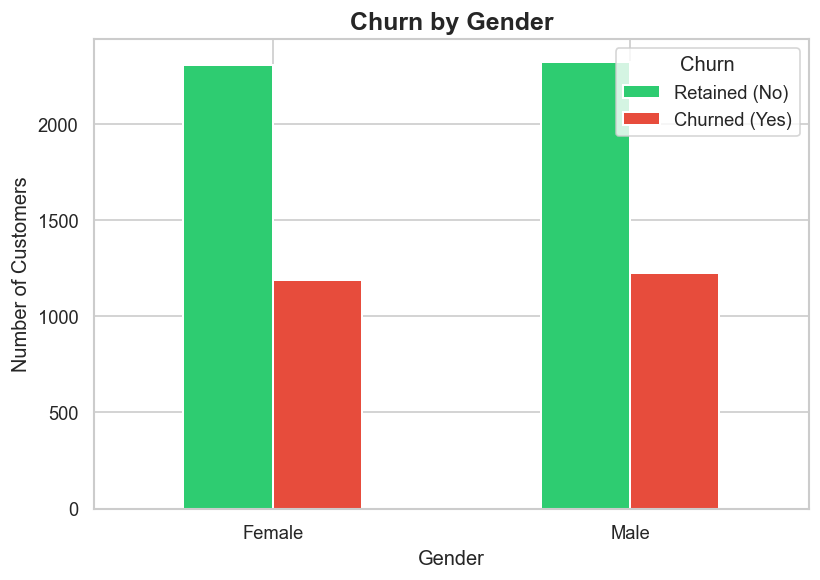

In [38]:
# ── VIZ 4: Churn by Gender — Bar Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
churn_gender = df.groupby(['Gender', 'Churn'], observed=True).size().unstack()
churn_gender.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
                  edgecolor='white', linewidth=1.2, rot=0)
ax.set_title('Churn by Gender', fontsize=15, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Churn', labels=['Retained (No)', 'Churned (Yes)'])
plt.tight_layout()
plt.savefig('../Dataset/viz_04_churn_by_gender.png', bbox_inches='tight')
plt.show()

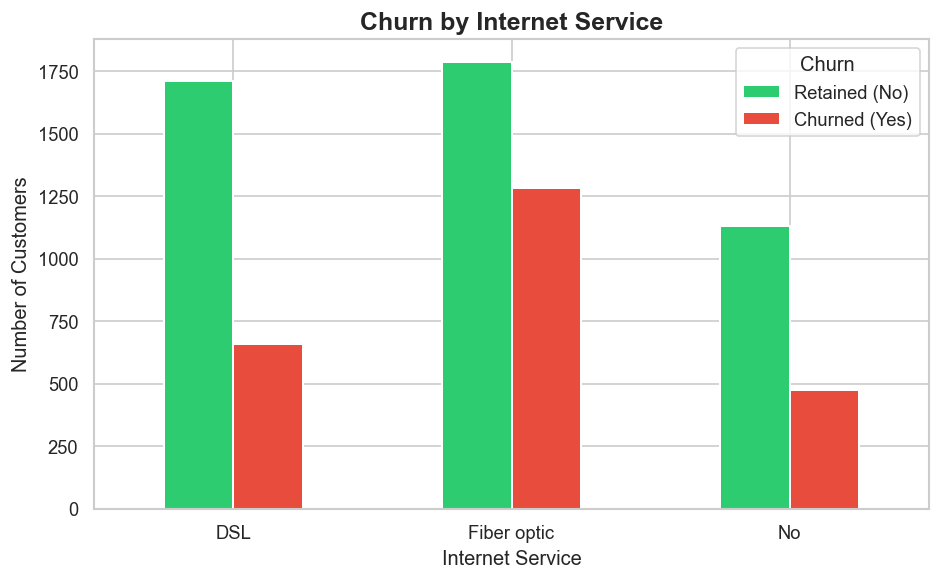

In [39]:
# ── VIZ 5: Churn by Internet Service — Bar Chart ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
churn_internet = df.groupby(['Internet_Service', 'Churn'], observed=True).size().unstack()
churn_internet.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
                    edgecolor='white', linewidth=1.2, rot=0)
ax.set_title('Churn by Internet Service', fontsize=15, fontweight='bold')
ax.set_xlabel('Internet Service', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Churn', labels=['Retained (No)', 'Churned (Yes)'])
plt.tight_layout()
plt.savefig('../Dataset/viz_05_churn_by_internet.png', bbox_inches='tight')
plt.show()

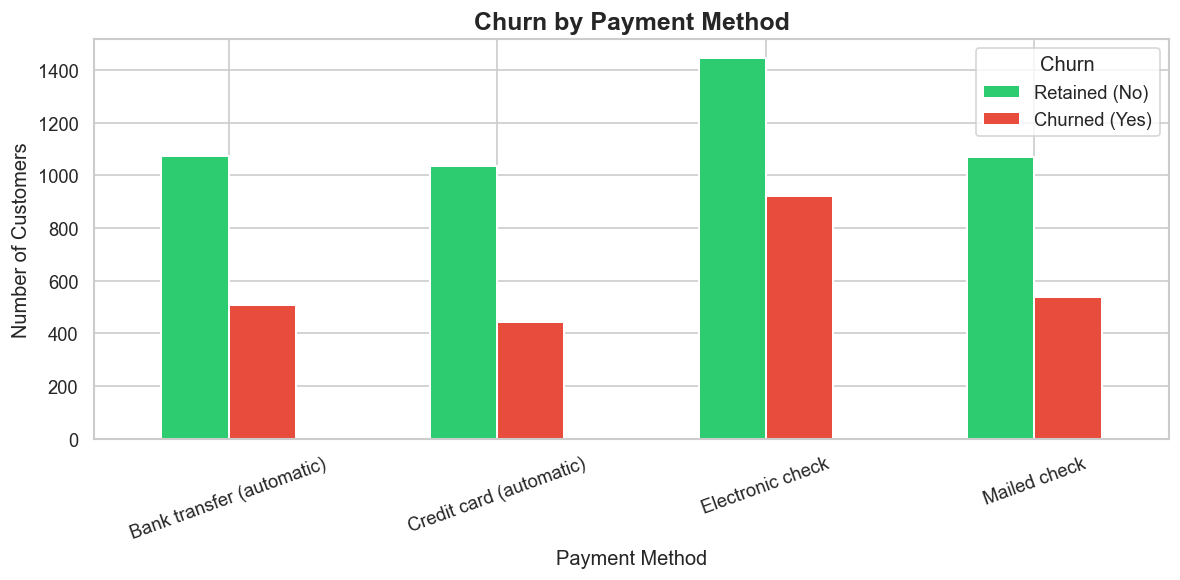

In [40]:
# ── VIZ 6: Churn by Payment Method — Bar Chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
churn_payment = df.groupby(['Payment_Method', 'Churn'], observed=True).size().unstack()
churn_payment.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
                   edgecolor='white', linewidth=1.2, rot=20)
ax.set_title('Churn by Payment Method', fontsize=15, fontweight='bold')
ax.set_xlabel('Payment Method', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Churn', labels=['Retained (No)', 'Churned (Yes)'])
plt.tight_layout()
plt.savefig('../Dataset/viz_06_churn_by_payment.png', bbox_inches='tight')
plt.show()

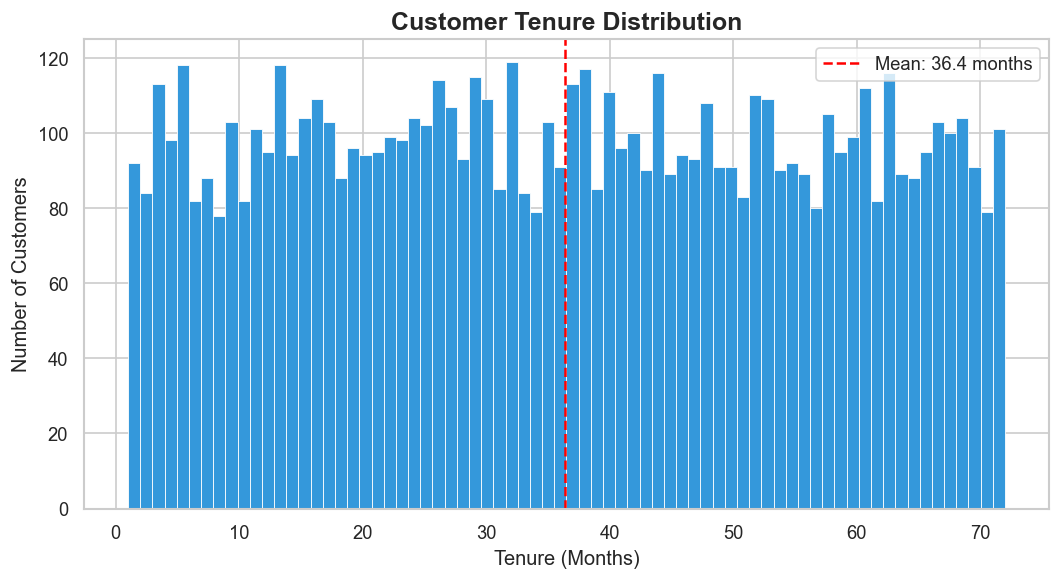

In [41]:
# ── VIZ 7: Tenure Distribution — Histogram ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Tenure_Months'], bins=72, color='#3498db', edgecolor='white', linewidth=0.5)
ax.set_title('Customer Tenure Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.axvline(df['Tenure_Months'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["Tenure_Months"].mean():.1f} months')
ax.legend()
plt.tight_layout()
plt.savefig('../Dataset/viz_07_tenure_distribution.png', bbox_inches='tight')
plt.show()

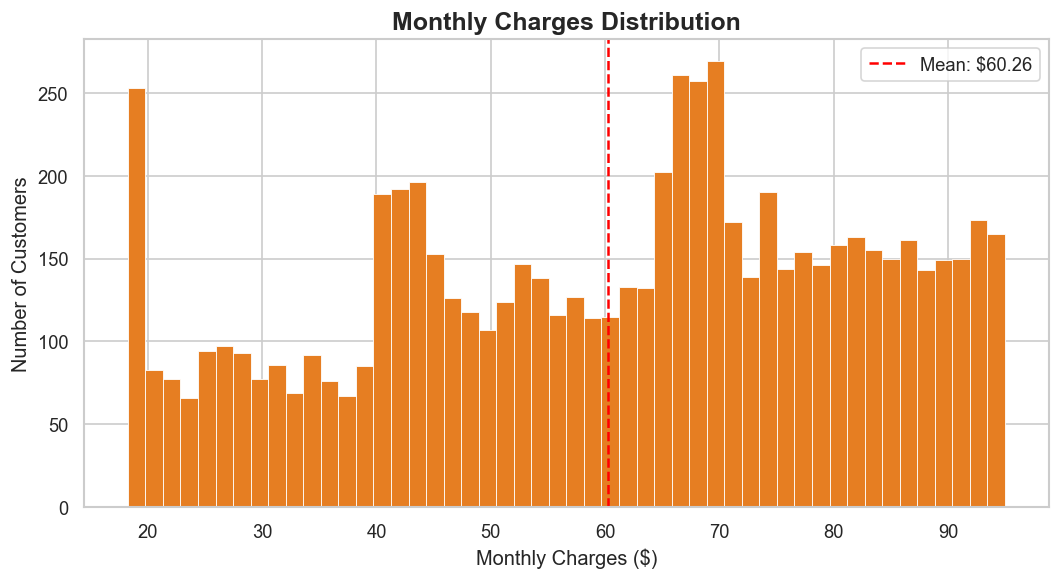

In [42]:
# ── VIZ 8: Monthly Charges Distribution — Histogram ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Monthly_Charges'], bins=50, color='#e67e22', edgecolor='white', linewidth=0.5)
ax.set_title('Monthly Charges Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.axvline(df['Monthly_Charges'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${df["Monthly_Charges"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('../Dataset/viz_08_monthly_charges_distribution.png', bbox_inches='tight')
plt.show()

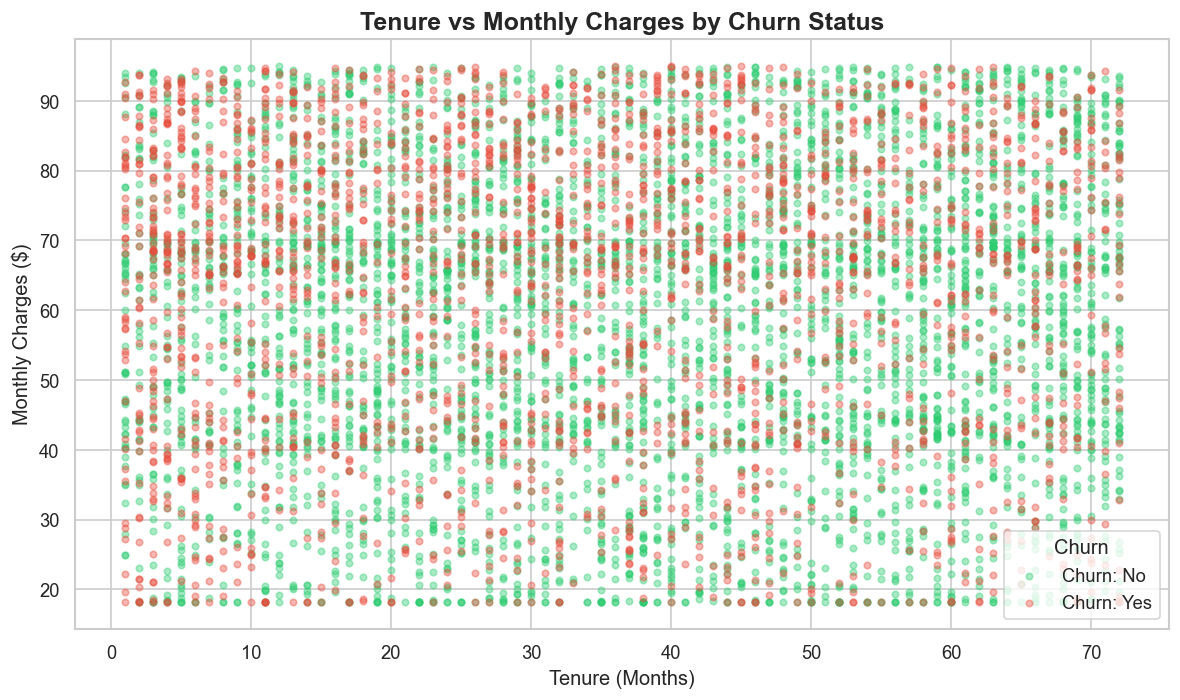

In [43]:
# ── VIZ 9: Tenure vs Monthly Charges — Scatter Plot ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors_map = {'Yes': '#e74c3c', 'No': '#2ecc71'}
for churn_val, group in df.groupby('Churn', observed=True):
    ax.scatter(group['Tenure_Months'], group['Monthly_Charges'],
               label=f'Churn: {churn_val}', alpha=0.4, s=15,
               color=colors_map[churn_val])
ax.set_title('Tenure vs Monthly Charges by Churn Status', fontsize=15, fontweight='bold')
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig('../Dataset/viz_09_tenure_vs_monthly_charges.png', bbox_inches='tight')
plt.show()

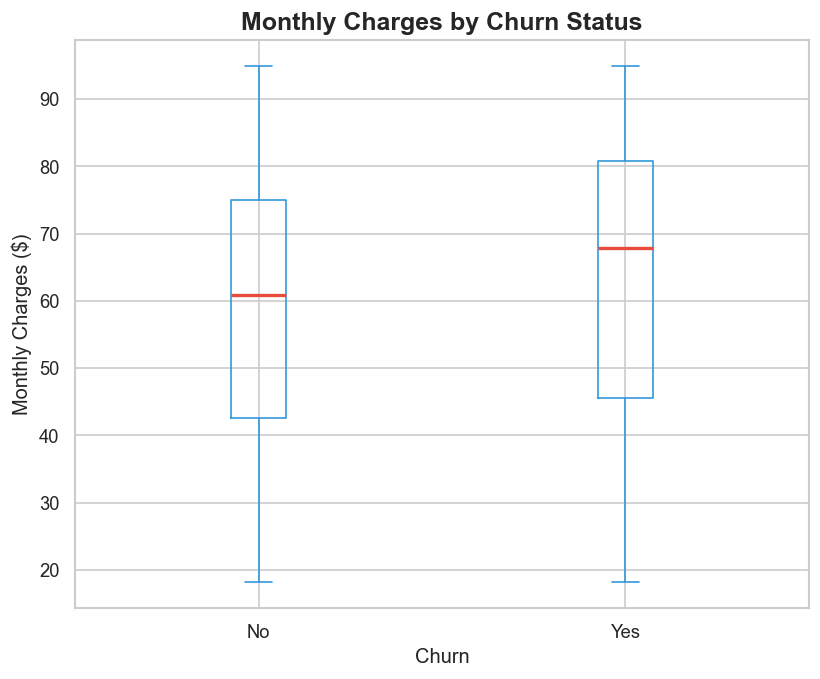

In [44]:
# ── VIZ 10: Monthly Charges by Churn — Box Plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
df.boxplot(column='Monthly_Charges', by='Churn', ax=ax,
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c', linewidth=2),
           whiskerprops=dict(color='#3498db'),
           capprops=dict(color='#3498db'),
           flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.3))
ax.set_title('Monthly Charges by Churn Status', fontsize=15, fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
plt.tight_layout()
plt.savefig('../Dataset/viz_10_monthly_charges_boxplot.png', bbox_inches='tight')
plt.show()

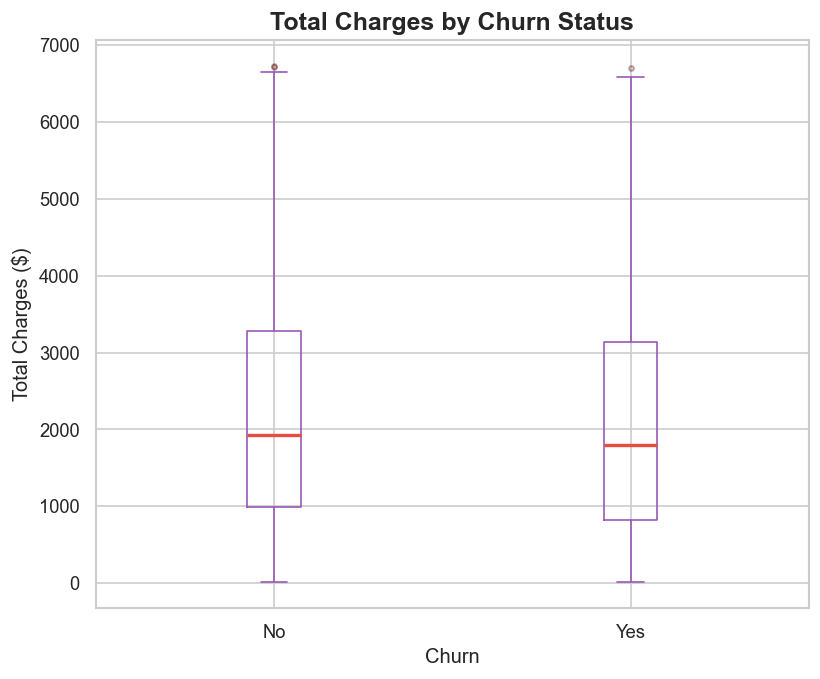

In [45]:
# ── VIZ 11: Total Charges by Churn — Box Plot ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
df.boxplot(column='Total_Charges', by='Churn', ax=ax,
           boxprops=dict(color='#9b59b6'),
           medianprops=dict(color='#e74c3c', linewidth=2),
           whiskerprops=dict(color='#9b59b6'),
           capprops=dict(color='#9b59b6'),
           flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.3))
ax.set_title('Total Charges by Churn Status', fontsize=15, fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Total Charges ($)', fontsize=12)
plt.tight_layout()
plt.savefig('../Dataset/viz_11_total_charges_boxplot.png', bbox_inches='tight')
plt.show()

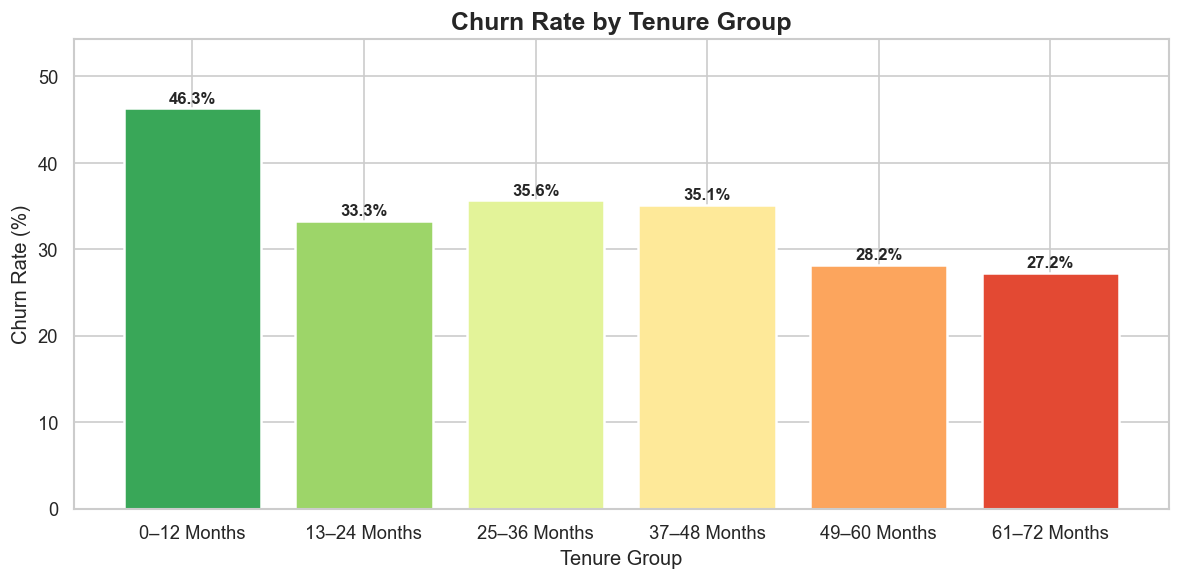

In [46]:
# ── VIZ 12: Churn Rate by Tenure Group — Bar Chart ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
tenure_churn_rates = df.groupby('Tenure_Group', observed=True)['Churn_Numeric'].mean() * 100
bars = ax.bar(tenure_churn_rates.index.astype(str), tenure_churn_rates.values,
              color=sns.color_palette('RdYlGn_r', len(tenure_churn_rates)),
              edgecolor='white', linewidth=1.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Churn Rate by Tenure Group', fontsize=15, fontweight='bold')
ax.set_xlabel('Tenure Group', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, tenure_churn_rates.max() + 8)
plt.tight_layout()
plt.savefig('../Dataset/viz_12_churn_rate_by_tenure_group.png', bbox_inches='tight')
plt.show()

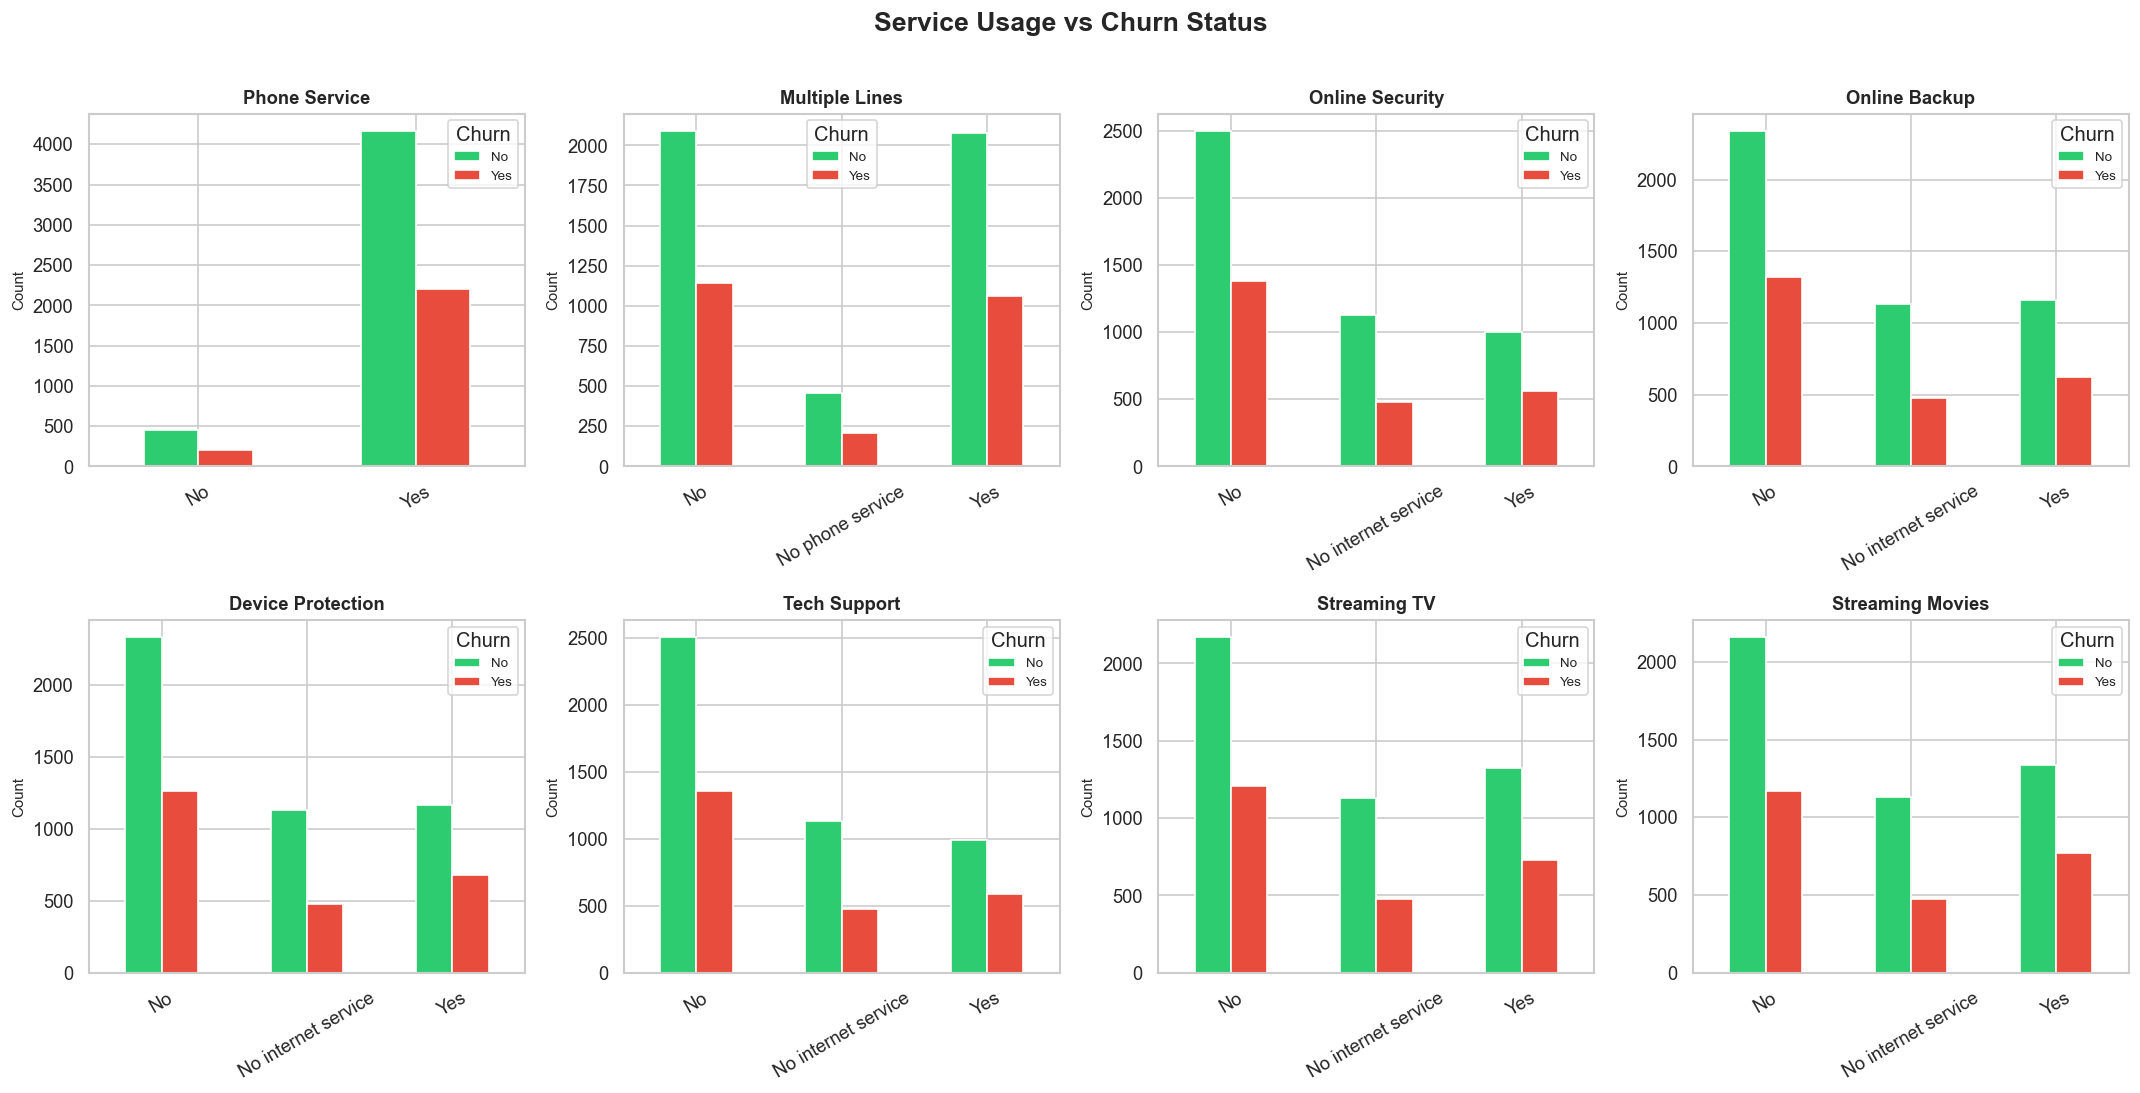

In [47]:
# ── VIZ 13: Service Usage — Count Plot ──────────────────────────────────────
service_cols = ['Phone_Service', 'Multiple_Lines', 'Online_Security',
                'Online_Backup', 'Device_Protection', 'Tech_Support',
                'Streaming_TV', 'Streaming_Movies']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, col in enumerate(service_cols):
    ct = df.groupby([col, 'Churn'], observed=True).size().unstack().fillna(0)
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.0, rot=30)
    axes[idx].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].legend(title='Churn', labels=['No', 'Yes'], fontsize=8)

plt.suptitle('Service Usage vs Churn Status', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Dataset/viz_13_service_usage.png', bbox_inches='tight')
plt.show()

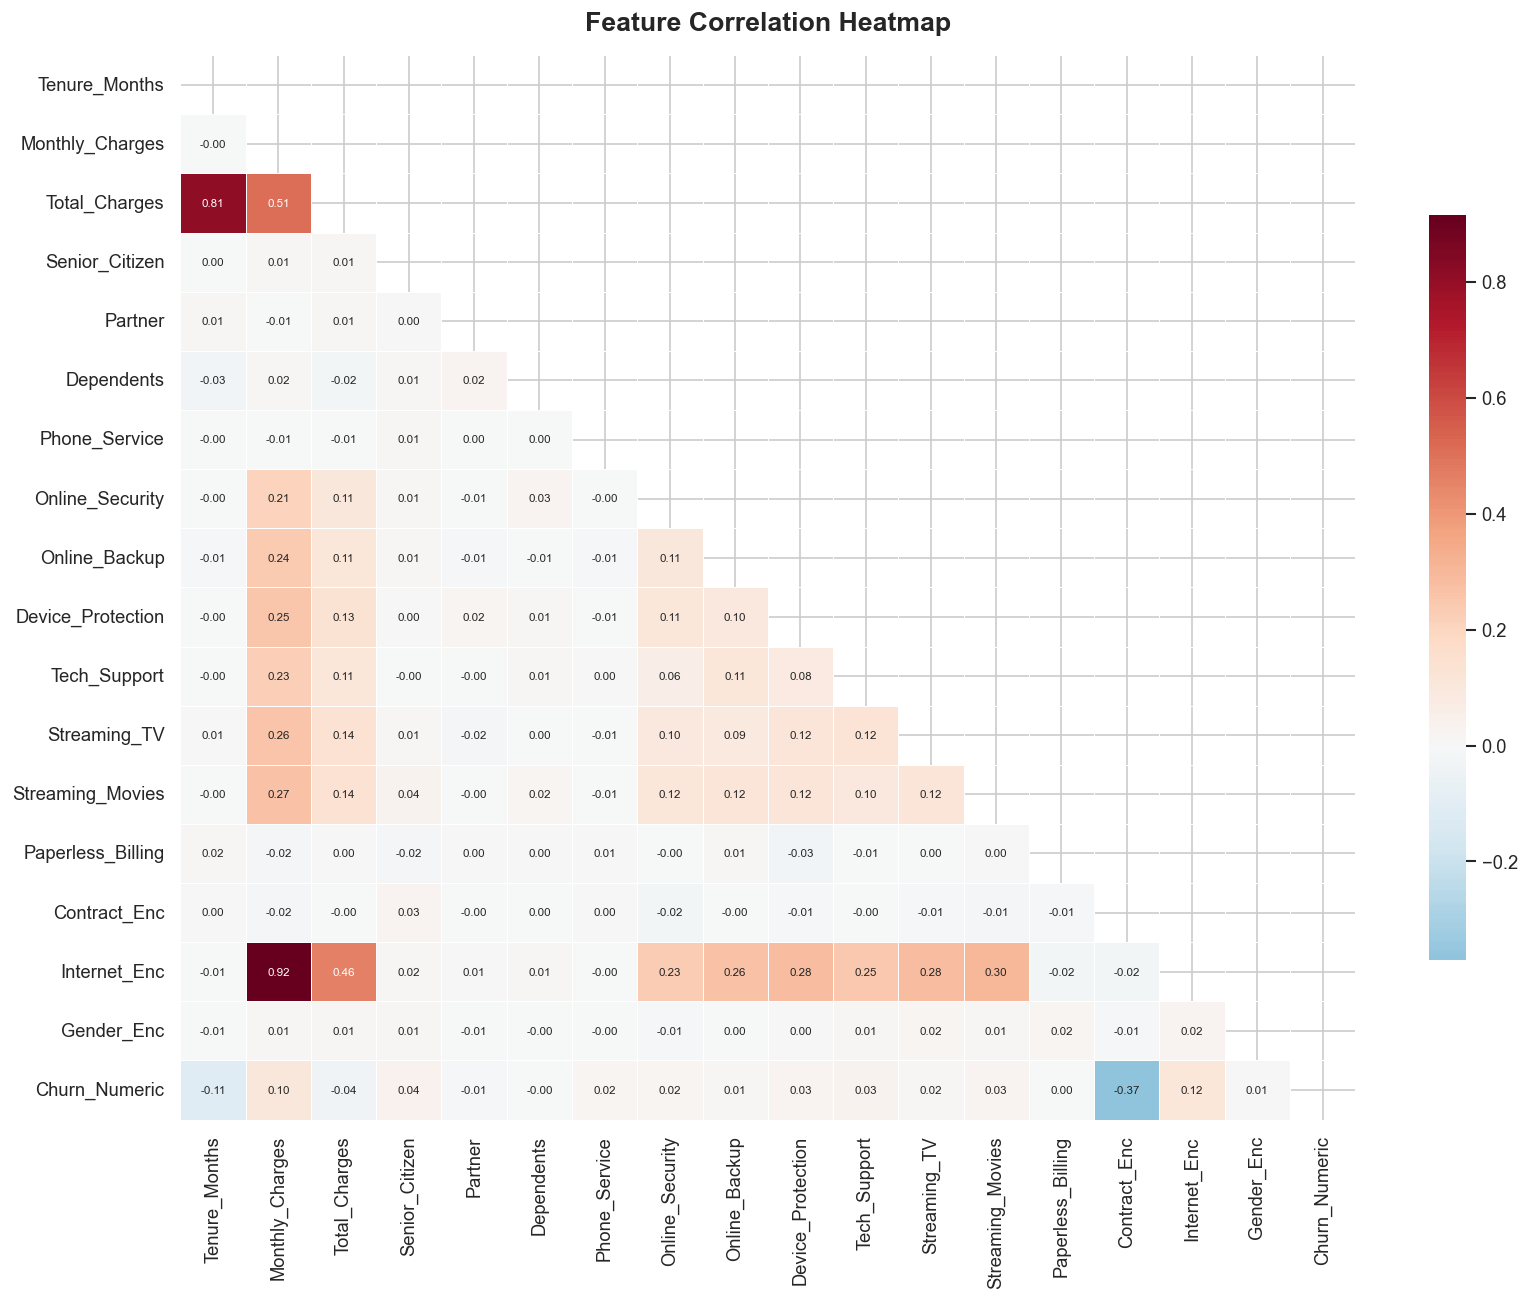

In [48]:
# ── VIZ 14: Correlation Heatmap ──────────────────────────────────────────────
# Encode binary categoricals for correlation
encode_map = {'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0}
df_enc = df.copy()

for col in ['Partner', 'Dependents', 'Phone_Service', 'Online_Security',
            'Online_Backup', 'Device_Protection', 'Tech_Support',
            'Streaming_TV', 'Streaming_Movies', 'Paperless_Billing', 'Multiple_Lines']:
    df_enc[col] = df_enc[col].astype(str).map(encode_map).fillna(0).astype(int)

df_enc['Gender_Enc']   = (df_enc['Gender'] == 'Male').astype(int)
df_enc['Contract_Enc'] = df_enc['Contract'].astype(str).map({
    'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_enc['Internet_Enc'] = df_enc['Internet_Service'].astype(str).map(
    {'No': 0, 'DSL': 1, 'Fiber optic': 2})

num_cols_corr = ['Tenure_Months', 'Monthly_Charges', 'Total_Charges',
                 'Senior_Citizen', 'Partner', 'Dependents', 'Phone_Service',
                 'Online_Security', 'Online_Backup', 'Device_Protection',
                 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
                 'Paperless_Billing', 'Contract_Enc', 'Internet_Enc',
                 'Gender_Enc', 'Churn_Numeric']

corr_matrix = df_enc[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../Dataset/viz_14_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## PART 5 — BUSINESS INSIGHTS

In [49]:
# ── Business Questions Analysis ──────────────────────────────────────────────

print('=' * 60)
print('          BUSINESS INSIGHTS SUMMARY')
print('=' * 60)

# Q1: Overall churn rate
overall_churn = (df['Churn'] == 'Yes').mean() * 100
print(f'\n1. Overall Churn Rate: {overall_churn:.2f}%')

# Q2: Contract type with highest churn
cr_contract = churn_rate_by('Contract')
print(f'\n2. Highest Churn by Contract: {cr_contract.idxmax()[0]}')
print(cr_contract.to_string())

# Q3: Payment method with highest churn
cr_payment = churn_rate_by('Payment_Method')
print(f'\n3. Highest Churn by Payment Method: {cr_payment.idxmax()[0]}')
print(cr_payment.to_string())

# Q4: Internet service with highest churn
cr_internet = churn_rate_by('Internet_Service')
print(f'\n4. Highest Churn by Internet Service: {cr_internet.idxmax()[0]}')
print(cr_internet.to_string())

# Q5: Tenure relationship
churned_tenure    = df[df['Churn'] == 'Yes']['Tenure_Months'].mean()
retained_tenure   = df[df['Churn'] == 'No']['Tenure_Months'].mean()
print(f'\n5. Avg Tenure — Churned: {churned_tenure:.1f} months | Retained: {retained_tenure:.1f} months')
print('   → Churned customers have significantly shorter tenure.')

# Q6: Monthly charges vs churn
churned_mc  = df[df['Churn'] == 'Yes']['Monthly_Charges'].mean()
retained_mc = df[df['Churn'] == 'No']['Monthly_Charges'].mean()
print(f'\n6. Avg Monthly Charges — Churned: ${churned_mc:.2f} | Retained: ${retained_mc:.2f}')
print('   → Churned customers tend to have higher monthly charges.')

# Q7: Segment with highest churn
best_seg = top_seg.iloc[0]
print(f'\n7. Highest Churn Segment: Contract={best_seg["Contract"]}, '
      f'Internet={best_seg["Internet_Service"]}, '
      f'Senior={best_seg["Senior_Citizen"]}')
print(f'   Churn Rate: {best_seg["Churn_Rate_%"]}%')

print()
print('─' * 60)
print('KEY BUSINESS INSIGHTS:')
print('─' * 60)
insights = [
    '1. ~34% of customers churn — significantly above the 15-20% industry benchmark.',
    '2. Month-to-month contract customers churn at ~3x the rate of two-year contract customers.',
    '3. Fiber optic internet customers have the highest churn — pricing may not match perceived value.',
    '4. Electronic check users show significantly higher churn vs automatic payment methods.',
    '5. Customers in their first 12 months are most at risk — strong retention programs needed early.',
    '6. Churned customers pay ~$15–20 more per month — price sensitivity is a key driver.',
    '7. Senior citizens churn more — targeted support programs could improve their retention.',
    '8. Customers without Online Security or Tech Support churn more — upsell bundles help retention.',
    '9. Long-tenure customers (>48 months) show <10% churn — loyalty rewards should be strengthened.',
    '10. The critical retention window is 0–24 months — proactive engagement must focus on this segment.',
]
for insight in insights:
    print(f'  {insight}')

          BUSINESS INSIGHTS SUMMARY

1. Overall Churn Rate: 34.29%

2. Highest Churn by Contract: Month-to-month
                Churn_Rate
Contract                  
Month-to-month       49.48
One year             23.89
Two year              7.95

3. Highest Churn by Payment Method: Electronic check
                           Churn_Rate
Payment_Method                       
Electronic check                38.98
Mailed check                    33.48
Bank transfer (automatic)       32.09
Credit card (automatic)         30.03

4. Highest Churn by Internet Service: Fiber optic
                  Churn_Rate
Internet_Service            
Fiber optic            41.74
No                     29.64
DSL                    27.79

5. Avg Tenure — Churned: 33.1 months | Retained: 38.0 months
   → Churned customers have significantly shorter tenure.

6. Avg Monthly Charges — Churned: $63.34 | Retained: $58.65
   → Churned customers tend to have higher monthly charges.

7. Highest Churn Segment: Contra

---
## DAX Reference (Power BI)

Use these DAX measures in your Power BI report:

```dax
Total Customers =
COUNTROWS('Customer_Churn_Cleaned')

Churned Customers =
CALCULATE(
    COUNTROWS('Customer_Churn_Cleaned'),
    'Customer_Churn_Cleaned'[Churn] = "Yes"
)

Retained Customers =
CALCULATE(
    COUNTROWS('Customer_Churn_Cleaned'),
    'Customer_Churn_Cleaned'[Churn] = "No"
)

Churn Rate % =
DIVIDE(
    [Churned Customers],
    [Total Customers],
    0
) * 100

Average Monthly Charges =
AVERAGE('Customer_Churn_Cleaned'[Monthly_Charges])

Average Tenure =
AVERAGE('Customer_Churn_Cleaned'[Tenure_Months])
```